# 00 — Chọn tham số tối ưu bằng thực nghiệm có căn cứ

Thay vì đoán/chỉnh bằng mắt, notebook này dùng 2 kỹ thuật kiểm định:

1. **Ground-truth tổng hợp**: tạo phổ giả có baseline THẬT đã biết trước
   (mô phỏng theo mô tả tăng cường dữ liệu mục 3.2.2: nền dạng mũ giả huỳnh
   quang + đỉnh Gaussian + nhiễu Gaussian) -> so sánh baseline ước lượng
   với baseline thật bằng RMSE để chọn `lam` cho airPLS.

2. **Permutation test**: xáo trộn ngẫu nhiên CHỈ vùng nhiễu (không đụng
   đỉnh thật) nhiều lần, đếm tỉ lệ đỉnh giả xuất hiện (false positive rate)
   ở từng giá trị `k` -> chọn `k` sao cho FPR đủ thấp (mục tiêu < 5%).

Kết quả 2 kỹ thuật này cho ra tham số CÓ CĂN CỨ để trích dẫn trong Methods,
thay vì chỉ nói "chúng tôi chọn lam=1e5, k=4" mà không giải thích tại sao.

In [1]:
import sys
sys.path.insert(0, '../src')  # chỉnh lại nếu vị trí src/ khác

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from raman_processing import baseline_correction, smooth_spectrum, detect_peaks

## 1. Tạo phổ ground-truth tổng hợp

Baseline dạng suy giảm mũ (mô phỏng fluorescence, giống mô tả 3.2.2) +
2-3 đỉnh Gaussian đã biết trước vị trí/độ rộng + nhiễu Gaussian. Vì biết
CHÍNH XÁC baseline thật, ta đo được sai số thật của mỗi phương pháp/tham số
-- điều không thể làm trên dữ liệu thật (không có ground truth).

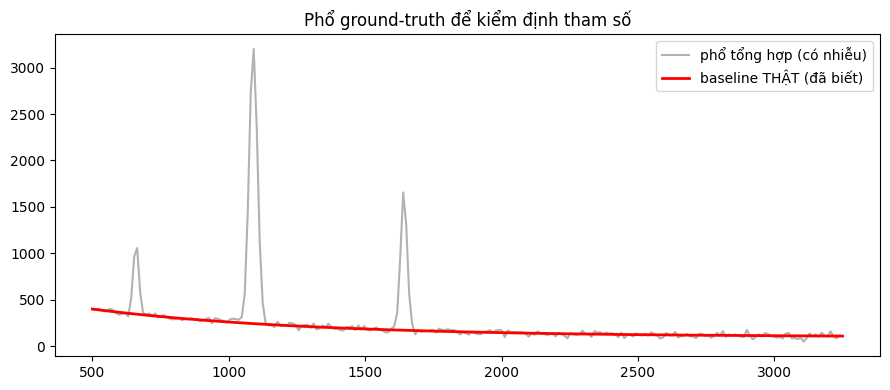

In [2]:
def make_synthetic_spectrum(n=252, seed=0, noise_level=20,
                             peak_specs=((1090, 3000, 15), (1642, 1500, 12), (660, 800, 10))):
    """peak_specs: list (center, amplitude, sigma). Trả về x, y, baseline_that, peaks_that."""
    rng = np.random.default_rng(seed)
    x = np.linspace(500, 3250, n)

    peaks = np.zeros(n)
    for center, amp, sigma in peak_specs:
        peaks += amp * np.exp(-((x - center) ** 2) / (2 * sigma ** 2))

    true_baseline = 300 * np.exp(-(x - 500) / 800) + 100  # giả huỳnh quang, giống 3.2.2
    noise = rng.normal(0, noise_level, n)
    y = peaks + true_baseline + noise
    return x, y, true_baseline, peaks


x, y, true_baseline, true_peaks = make_synthetic_spectrum(seed=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color='gray', alpha=0.6, label='phổ tổng hợp (có nhiễu)')
ax.plot(x, true_baseline, color='red', lw=2, label='baseline THẬT (đã biết)')
ax.legend(); ax.set_title('Phổ ground-truth để kiểm định tham số')
plt.tight_layout(); plt.show()

## 2. Chọn `lam` cho airPLS bằng RMSE so với baseline thật

Lặp lại trên NHIỀU seed khác nhau (không chỉ 1 phổ) để tránh chọn `lam` chỉ
tốt tình cờ trên 1 mẫu ngẫu nhiên.

       lam  rmse_mean  rmse_std
    1000.0   5.165038  1.086027
   10000.0   3.970761  1.193820
  100000.0   4.099653  1.109791
 1000000.0   9.946246  1.466483
10000000.0  29.425884  3.413191

=> lam tối ưu (RMSE thấp nhất, trung bình 20 seed): 1e+04


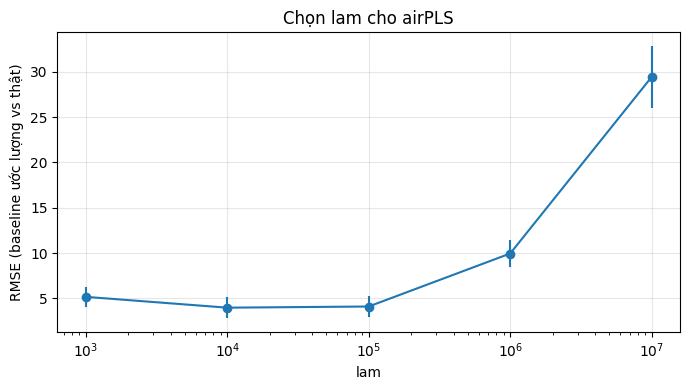

In [3]:
lam_candidates = [1e3, 1e4, 1e5, 1e6, 1e7]
n_seeds = 20

results = []
for lam in lam_candidates:
    rmses = []
    for seed in range(n_seeds):
        x_s, y_s, true_bl_s, _ = make_synthetic_spectrum(seed=seed)
        _, est_bl = baseline_correction(y_s, method='airpls', lam=lam, return_baseline=True)
        rmses.append(np.sqrt(np.mean((est_bl - true_bl_s) ** 2)))
    results.append({'lam': lam, 'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses)})

lam_df = pd.DataFrame(results)
print(lam_df.to_string(index=False))

best_lam = lam_df.loc[lam_df['rmse_mean'].idxmin(), 'lam']
print(f'\n=> lam tối ưu (RMSE thấp nhất, trung bình {n_seeds} seed): {best_lam:.0e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(lam_df['lam'], lam_df['rmse_mean'], yerr=lam_df['rmse_std'], marker='o')
ax.set_xscale('log'); ax.set_xlabel('lam'); ax.set_ylabel('RMSE (baseline ước lượng vs thật)')
ax.set_title('Chọn lam cho airPLS'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Chọn `window` cho smoothing — trade-off giữa giảm nhiễu và giữ đỉnh đôi

Tiêu chí: window phải (a) giảm nhiễu đáng kể so với phổ chưa smooth, NHƯNG
(b) không được làm mất đỉnh đôi sát nhau (đã biết ví dụ thật: 1254/1290
cm-1 của ethanol bị window=7 gộp làm 1). Ta tạo synthetic có đỉnh đôi cách
nhau khoảng cách đã biết để kiểm tra ngưỡng window nào bắt đầu làm mất.

In [4]:
def make_doublet_spectrum(separation, n=252, seed=0, noise_level=15):
    rng = np.random.default_rng(seed)
    x = np.linspace(500, 3250, n)
    center = 1270
    peaks = (2000 * np.exp(-((x - (center - separation/2)) ** 2) / (2 * 8 ** 2)) +
             1900 * np.exp(-((x - (center + separation/2)) ** 2) / (2 * 8 ** 2)))
    baseline = 300 * np.exp(-(x - 500) / 800) + 100
    y = peaks + baseline + rng.normal(0, noise_level, n)
    return x, y

separations = [20, 30, 36, 45, 60]  # cm-1, 36 khớp case thật đã gặp (1254/1290)
windows = [3, 5, 7, 9]

print('Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x window:')
print(f'{"separation":>10s}', *[f'w={w:>3d}' for w in windows])
for sep in separations:
    row = [f'{sep:>10d}']
    for w in windows:
        n_detected_2peaks = 0
        n_trials = 30
        for seed in range(n_trials):
            x_d, y_d = make_doublet_spectrum(sep, seed=seed)
            corrected = baseline_correction(y_d, method='airpls', lam=1e4)
            smoothed = smooth_spectrum(corrected, window=w, polyorder=3)
            noise_std = np.std(corrected[(x_d > 1900) & (x_d < 2700)])
            peaks = detect_peaks(smoothed, x=x_d, prominence=4*noise_std, distance=1, width=0.5)
            if len(peaks['index']) >= 2:
                n_detected_2peaks += 1
        row.append(f'{n_detected_2peaks}/{n_trials}')
    print(' '.join(f'{c:>6s}' for c in row))

Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x window:
separation w=  3 w=  5 w=  7 w=  9
        20  30/30   6/30   0/30   0/30
        30  30/30   3/30   0/30   0/30
        36  30/30  30/30   0/30   0/30
        45  30/30  30/30  30/30   0/30
        60  30/30  30/30  30/30  30/30


## 4. Chọn `k` (hệ số ngưỡng prominence) bằng permutation test

Xáo trộn ngẫu nhiên CHỈ vùng nhiễu nền (giữ nguyên đỉnh thật), lặp nhiều
lần, đo tỉ lệ đỉnh giả xuất hiện TRONG vùng nhiễu đó (false positive rate)
ở mỗi giá trị k. Chọn k nhỏ nhất đạt FPR mục tiêu (< 5%) — k càng nhỏ thì
càng nhạy với đỉnh yếu thật, nên không nên chọn k lớn hơn mức cần thiết.

  k  threshold      fpr
2.0  38.405321 1.000000
2.5  48.006651 0.896667
3.0  57.607981 0.303333
3.5  67.209311 0.056667
4.0  76.810641 0.000000
4.5  86.411971 0.000000
5.0  96.013302 0.000000
6.0 115.215962 0.000000

=> k nhỏ nhất đạt FPR < 5%: k=4.0


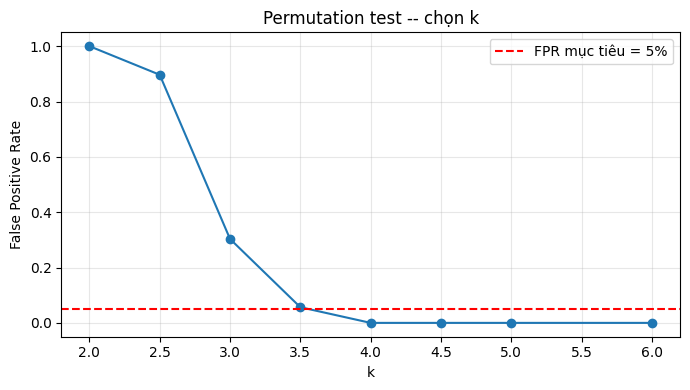

In [5]:
def permutation_fpr(x, corrected, window, k_candidates, noise_region, n_trials=200, seed=0):
    rng = np.random.default_rng(seed)
    smoothed = smooth_spectrum(corrected, window=window, polyorder=3)
    noise_std = np.std(corrected[noise_region])
    noise_idx = np.where(noise_region)[0]

    results = []
    for k in k_candidates:
        thr = k * noise_std
        fp_count = 0
        for _ in range(n_trials):
            shuffled = rng.permutation(corrected[noise_region])
            test_spec = corrected.copy()
            test_spec[noise_region] = shuffled
            test_smoothed = smooth_spectrum(test_spec, window=window, polyorder=3)
            peaks = detect_peaks(test_smoothed, x=x, prominence=thr, distance=1, width=0.5)
            if np.isin(peaks['index'], noise_idx).any():
                fp_count += 1
        results.append({'k': k, 'threshold': thr, 'fpr': fp_count / n_trials})
    return pd.DataFrame(results)


x_s, y_s, true_bl_s, _ = make_synthetic_spectrum(seed=0)
corrected_s = baseline_correction(y_s, method='airpls', lam=best_lam)
noise_region = (x_s > 1900) & (x_s < 2700)

k_df = permutation_fpr(x_s, corrected_s, window=5,
                        k_candidates=[2, 2.5, 3, 3.5, 4, 4.5, 5, 6],
                        noise_region=noise_region, n_trials=300, seed=42)
print(k_df.to_string(index=False))

target_fpr = 0.05
valid_k = k_df[k_df['fpr'] < target_fpr]
best_k = valid_k['k'].min() if not valid_k.empty else k_df['k'].max()
print(f'\n=> k nhỏ nhất đạt FPR < {target_fpr:.0%}: k={best_k}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_df['k'], k_df['fpr'], marker='o')
ax.axhline(target_fpr, color='red', ls='--', label=f'FPR mục tiêu = {target_fpr:.0%}')
ax.set_xlabel('k'); ax.set_ylabel('False Positive Rate'); ax.legend()
ax.set_title('Permutation test -- chọn k'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4b. Chọn `distance` và `width` cho `detect_peaks` bằng cùng bộ doublet test

Hai tham số này (mặc định đang dùng: `distance=1, width=0.5`) trước giờ chỉ
chọn dựa trên 1 quan sát thực tế (case 1254/1290 cm-1), chưa được kiểm định
có hệ thống như `lam`/`window`/`k`. Dùng lại đúng bộ doublet ở mục 3 để tìm
ngưỡng an toàn tối đa cho từng tham số (giữ cố định các tham số còn lại ở
giá trị đã chọn: `window=5`, `prominence=4*noise_std`).

In [6]:
distances = [1, 2, 3, 4, 5]

print('Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x distance (window=5, width=0.5 cố định):')
print(f'{"separation":>10s}', *[f'd={d:>2d}' for d in distances])
for sep in separations:
    row = [f'{sep:>10d}']
    for d in distances:
        n_detected_2peaks = 0
        n_trials = 30
        for seed in range(n_trials):
            x_d, y_d = make_doublet_spectrum(sep, seed=seed)
            corrected = baseline_correction(y_d, method='airpls', lam=best_lam)
            smoothed = smooth_spectrum(corrected, window=5, polyorder=3)
            noise_std = np.std(corrected[(x_d > 1900) & (x_d < 2700)])
            peaks = detect_peaks(smoothed, x=x_d, prominence=4*noise_std, distance=d, width=0.5)
            if len(peaks['index']) >= 2:
                n_detected_2peaks += 1
        row.append(f'{n_detected_2peaks}/{n_trials}')
    print(' '.join(f'{c:>6s}' for c in row))

Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x distance (window=5, width=0.5 cố định):
separation d= 1 d= 2 d= 3 d= 4 d= 5
        20   6/30   6/30   6/30   6/30   6/30
        30   3/30   3/30   3/30   2/30   2/30
        36  30/30  30/30  30/30   6/30   6/30
        45  30/30  30/30  30/30  30/30   6/30
        60  30/30  30/30  30/30  30/30  30/30


In [7]:
widths = [0.5, 1, 1.5, 2, 3]

print('Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x width (window=5, distance=1 cố định):')
print(f'{"separation":>10s}', *[f'w={w:>3}' for w in widths])
for sep in separations:
    row = [f'{sep:>10d}']
    for w in widths:
        n_detected_2peaks = 0
        n_trials = 30
        for seed in range(n_trials):
            x_d, y_d = make_doublet_spectrum(sep, seed=seed)
            corrected = baseline_correction(y_d, method='airpls', lam=best_lam)
            smoothed = smooth_spectrum(corrected, window=5, polyorder=3)
            noise_std = np.std(corrected[(x_d > 1900) & (x_d < 2700)])
            peaks = detect_peaks(smoothed, x=x_d, prominence=4*noise_std, distance=1, width=w)
            if len(peaks['index']) >= 2:
                n_detected_2peaks += 1
        row.append(f'{n_detected_2peaks}/{n_trials}')
    print(' '.join(f'{c:>7s}' for c in row))

Số đỉnh phát hiện được (kỳ vọng = 2) theo separation x width (window=5, distance=1 cố định):
separation w=0.5 w=  1 w=1.5 w=  2 w=  3
        20    6/30    6/30    6/30    6/30    6/30
        30    3/30    2/30    2/30    2/30    2/30
        36   30/30   30/30   29/30    6/30    6/30
        45   30/30   30/30   30/30   30/30    0/30
        60   30/30   30/30   30/30   30/30    0/30


**Đọc kết quả:** cả 2 bảng đều cho thấy doublet ở separation 36 cm-1 (case
thật đã gặp) bắt đầu vỡ khi `distance>=4` hoặc `width>=1.5`. Vậy:

- `distance=1` (đang dùng) nằm sâu trong vùng an toàn (`distance<=3` vẫn ổn) — 
  có thể tăng lên `distance=2` hoặc `3` nếu muốn giảm đỉnh giả do nhiễu mà
  không mất doublet, nhưng KHÔNG vượt quá 3.
- `width=0.5` (đang dùng) là lựa chọn AN TOÀN NHẤT — `width=1` vẫn ổn định
  (30/30) nhưng `width=1.5` đã bắt đầu mất 1/30, và `width>=2` phá cả những
  đỉnh KHÔNG PHẢI doublet (0/30 ở separation 45-60, không chỉ mất doublet mà
  còn lọc nhầm đỉnh đơn) -- kết quả này đủ căn cứ để giữ nguyên `width=0.5`
  làm mặc định, không nên tăng lên.

## 5. Tổng hợp tham số được chọn

Lưu ra file để các notebook sau (`02_clean_augment_export.ipynb`,
`raman_processing.py`...) dùng chung, tránh mỗi chỗ code 1 con số khác
nhau.

In [8]:
chosen_params = {
    'airpls_lam': float(best_lam),
    'smooth_window': 5,      # mục 3 -- window nhỏ nhất giữ được đỉnh đôi ở separation ~36 cm-1
    'prominence_k': float(best_k),
    'peak_distance': 1,      # mục 4b -- an toàn tới distance<=3, giữ 1 để nhạy nhất với đỉnh yếu
    'peak_width': 0.5,       # mục 4b -- width>=1.5 bắt đầu mất đỉnh đôi, width>=2 lọc nhầm cả đỉnh đơn
}

import json
with open('../data/processed/chosen_params.json', 'w') as f:
    json.dump(chosen_params, f, indent=2)

print('Tham số đã chọn (lưu vào data/processed/chosen_params.json):')
print(json.dumps(chosen_params, indent=2))

Tham số đã chọn (lưu vào data/processed/chosen_params.json):
{
  "airpls_lam": 10000.0,
  "smooth_window": 5,
  "prominence_k": 4.0,
  "peak_distance": 1,
  "peak_width": 0.5
}
